In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# Load dataset
df = pd.read_csv("AIML Dataset.csv")

# Drop columns that are not useful
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

# Define categorical and numeric columns
categorical = ["type"]
numeric = [col for col in df.columns if col not in categorical + ['isFraud', 'isFlaggedFraud']]

# Define features and target
X = df.drop(['isFraud', 'isFlaggedFraud'], axis=1)
y = df['isFraud']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [2]:
# Define preprocessing: standard scaling for numeric, one-hot for categorical
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ]
)

# Define the XGBoost model
from xgboost import XGBClassifier
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Create pipeline
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", model)
])

# Fit the model
pipeline.fit(X_train, y_train)



Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['step', 'amount',
                                                   'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, devi...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [21]:
# Predict and evaluate
from sklearn.metrics import classification_report, confusion_matrix, precision_score
y_probs = pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= 0.05).astype(int)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.54      0.91      0.68      1643

    accuracy                           1.00   1272524
   macro avg       0.77      0.96      0.84   1272524
weighted avg       1.00      1.00      1.00   1272524

Confusion Matrix:
 [[1269597    1284]
 [    140    1503]]
Precision: 0.5392895586652314


Original Row (with labels):
step                     230
type                 CASH_IN
amount             236314.26
oldbalanceOrg      823813.46
newbalanceOrig    1060127.71
oldbalanceDest    4143568.59
newbalanceDest    3907254.34
isFraud                    0
isFlaggedFraud             0
Name: 2945984, dtype: object

Fraud Probability for the selected transaction: 0.0000


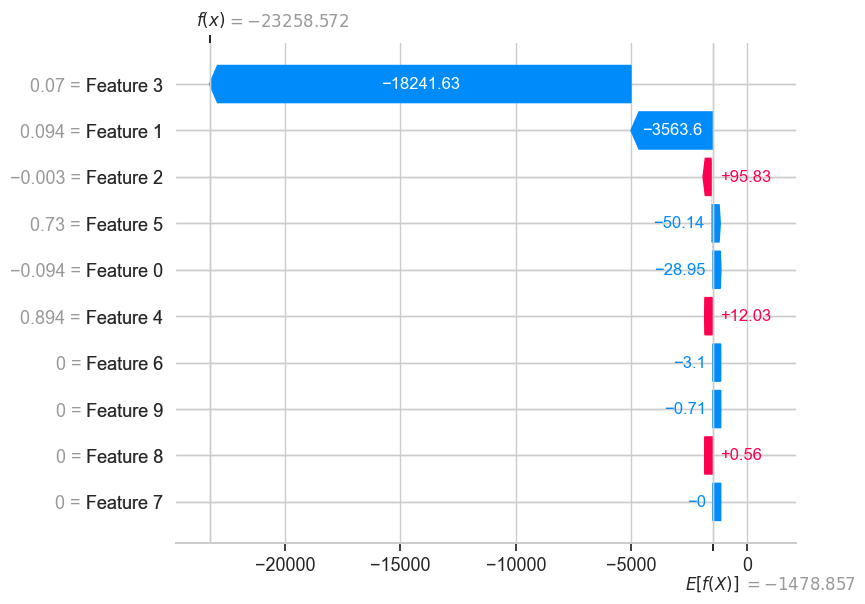

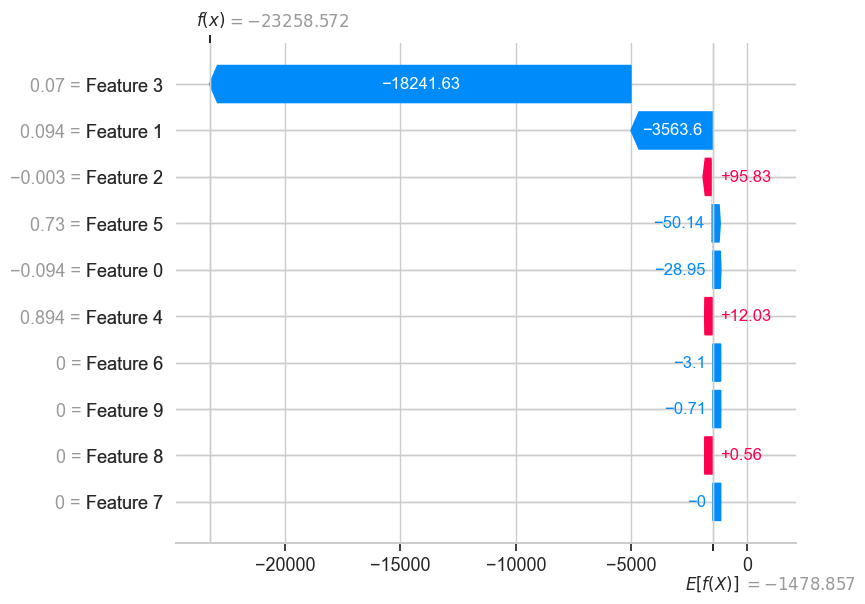

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

#Select one sample
row = X_test.iloc[[1]]

# Step 1: Get the test row and its original index
original_index = row.index[0]

# Step 2: Print the full original row from the DataFrame (includes 'isFraud' and 'isFlaggedFraud')
print("Original Row (with labels):")
print(df.loc[original_index])

# Extract model and transform input row
transformed_row = pipeline.named_steps['prep'].transform(row)
transformed_data = pipeline.named_steps['prep'].transform(X_test)

# Fit SHAP explainer
explainer = shap.Explainer(pipeline.named_steps['clf'], transformed_data)

# Get SHAP values for one sample
shap_values = explainer(transformed_row)

# Show predicted fraud probability
fraud_prob = pipeline.predict_proba(row)[0][1]
print(f"\nFraud Probability for the selected transaction: {fraud_prob:.4f}")

# Plot SHAP values (how each feature contributed)
shap.plots.waterfall(shap_values[0], max_display=15)
shap.plots.waterfall(shap_values[0], max_display=15)


In [23]:
import joblib
joblib.dump(pipeline,"fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']